### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [5]:
data = pd.read_csv('assignment5_1_starter/data/coupons.csv')

In [6]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [7]:
#Understand more about the columns, their null values and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

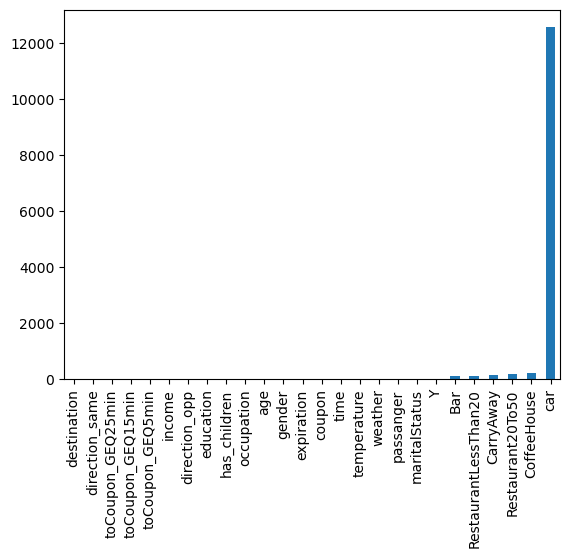

In [8]:
#Generate a quick plot to show which features have missing data
data.isnull().sum().sort_values().plot(kind = 'bar')
plt.show()

In [9]:
#Get the actual counts of missing data for the features
missing = data.isnull().sum()
features_missing = missing[missing > 0].to_frame(name = "Missing Value Total")
features_missing


,Missing Value Total
car,12576
Bar,107
CoffeeHouse,217
CarryAway,151
RestaurantLessThan20,130
Restaurant20To50,189


We can see car has many missing values (12,576), and Bar, CoffeeHouse, CarryAway and RestaurantLessThan20, and Restaurant20To50 also have missing values to deal with.

In [10]:
#Look at what values Car takes on
car_values = data['car'].value_counts()
car_values

car
Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: count, dtype: int64

Althought it's possible there's some correlation between the type of car one would drive and the uptake of coupons, the data looks bad. We just won't use this feature.

In [11]:
#Look at what values bar, CoffeeHouse, CarryAway, RestaurantLessThan20 and Restaurant20To50 take on
bar_values = data['Bar'].value_counts()
print(bar_values)
coffeehouse_values = data['CoffeeHouse'].value_counts()
print(coffeehouse_values)
carryaway_values = data['CarryAway'].value_counts()
print(carryaway_values)
restaurantlessthan20 = data['RestaurantLessThan20'].value_counts()
print(restaurantlessthan20)
restaurant20to50 = data['Restaurant20To50'].value_counts()
print(restaurant20to50)

Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64


It's helpful to see the values each variable takes on and we can drop the missing values in several of these variables because it wouldn't make sense to impute them and there are so few of them.

#Problematic Data - look for outliers

3. Decide what to do about your missing data -- drop, replace, other...

In [38]:
#Dropping the observations with missing values in several columns that are used in subsequent analyses to see what we end up with. Started with 12684 entries
data = data.dropna(subset = ['Bar','RestaurantLessThan20'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12489 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12489 non-null  object
 1   passanger             12489 non-null  object
 2   weather               12489 non-null  object
 3   temperature           12489 non-null  int64 
 4   time                  12489 non-null  object
 5   coupon                12489 non-null  object
 6   expiration            12489 non-null  object
 7   gender                12489 non-null  object
 8   age                   12489 non-null  object
 9   maritalStatus         12489 non-null  object
 10  has_children          12489 non-null  int64 
 11  education             12489 non-null  object
 12  occupation            12489 non-null  object
 13  income                12489 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12489 non-null  obj

We have a dataset without missing values (except car) and 12,489 entries, which doesn't seem like too many dropped when we started with 12684 entries

4. What proportion of the total observations chose to accept the coupon?



In [39]:
#Look at the count of each
coupon_values = data['Y'].value_counts()
print(coupon_values)
#Calculate the proportion
coupon_total = data['Y'].mean()
print(coupon_total)

Y
1    7095
0    5394
Name: count, dtype: int64
0.5680999279365841


56.81% accepted the coupon

5. Use a bar plot to visualize the `coupon` column.

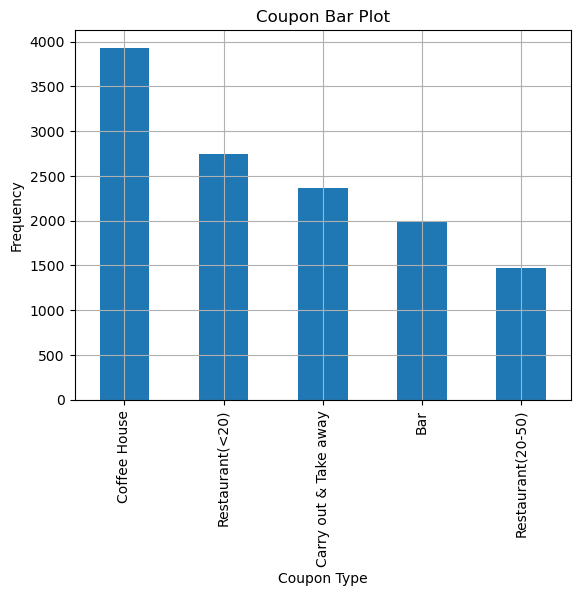

In [14]:
#Generate a bar plot of the counts of each of the values of the coupon column
coupon_plot = data['coupon'].value_counts().plot(kind = 'bar', grid=True, xlabel = "Coupon Type", ylabel= 'Frequency', title= 'Coupon Bar Plot')

6. Use a histogram to visualize the temperature column.

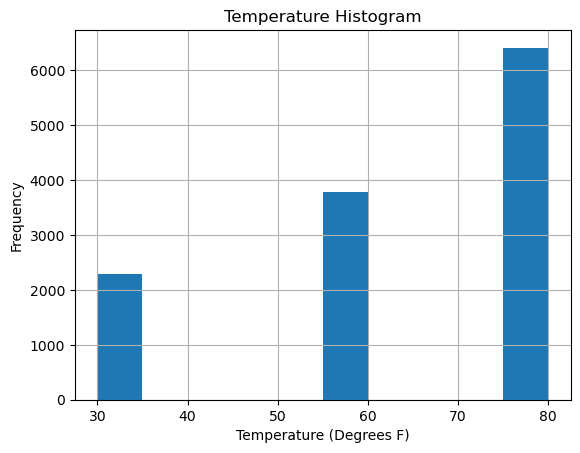

In [15]:
#Creating the histogram of temperature
temp_plot = data['temperature'].plot(kind = 'hist', grid=True, xlabel="Temperature (Degrees F)", title = 'Temperature Histogram')

This plot reveals that the temperature data is a bit strange, in my opinion. All of the temperatures fall into only three categories? This seems unlikley somehow, but without knowing where the data was collected and how, it's hard to say what is going on.

Text(0.5, 1.0, 'Boxplot of Time')

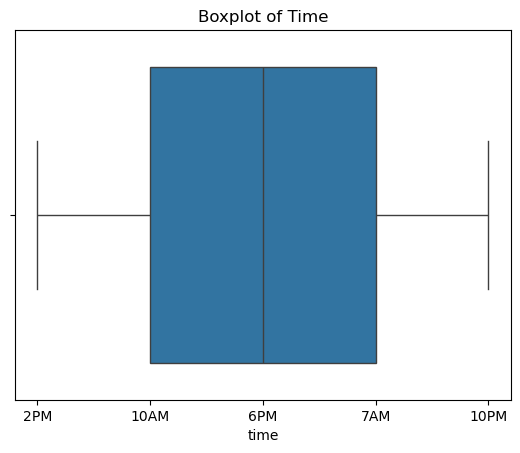

In [16]:
#Seaborn boxplot of the time variable just to explore
sns.boxplot(data=data, x='time').set_title('Boxplot of Time')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [17]:
#Look at the overall coupon types
coupontype_values = data['coupon'].value_counts()
coupontype_values

coupon
Coffee House             3930
Restaurant(<20)          2745
Carry out & Take away    2360
Bar                      1982
Restaurant(20-50)        1472
Name: count, dtype: int64

In [18]:
#Creating a dataframe with only bar coupons
bar_df = data[data['coupon'] == 'Bar']
bar_df



,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [19]:
#Create the count of 1 and 0 for the Y variable
bar_accepted = bar_df['Y'].value_counts()
print(bar_accepted)
#Calculate the proportion of those who accepted
bar_prop_accepted = bar_df['Y'].mean()
print(bar_prop_accepted)


Y
0    1170
1     812
Name: count, dtype: int64
0.40968718466195764


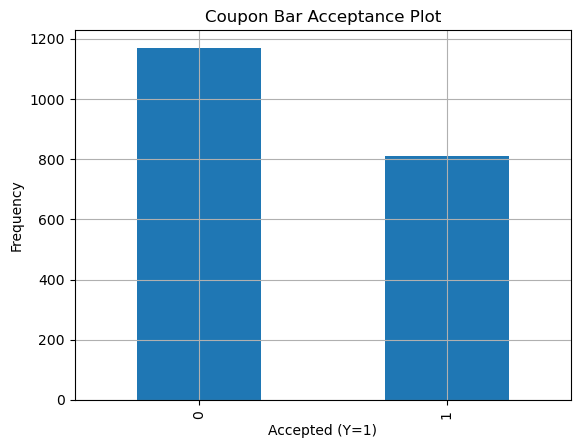

In [20]:
#Generate a bar plot of the acceptance
bar_df_barplot = bar_df['Y'].value_counts().plot(kind = 'bar', grid=True, xlabel = "Accepted (Y=1)", ylabel= 'Frequency', title= 'Coupon Bar Acceptance Plot')

40.96% accepted the bar coupons

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [21]:
#Look at the bar values again
bar_df['Bar'].value_counts()


Bar
never    822
less1    564
1~3      397
4~8      150
gt8       49
Name: count, dtype: int64

In [22]:
#Get the acceptance rate of those who went to a bar 3 or fewer times (inclues values of: never, less1, 1~3) 
threeorfewerquery = bar_df.query("Bar in ['never','less1','1~3']")['Y'].mean()
threeorfewerquery

np.float64(0.36960179472798654)

36.96% acceptance rate of those who went to a bar 3 times or fewer

In [23]:
#Get the acceptance rate of those who went to a bar 4 or more times (inclues values of: 4~8, gt8) 
fourormorequery = bar_df.query("Bar in ['4~8', 'gt8']")['Y'].mean()
fourormorequery

np.float64(0.7688442211055276)

76.88% acceptance rate of those who went to a bar 4 times or more, compared with 36.96% acceptance rate of those who went to a bar 3 times or fewer. So there's a higher acceptance rate of the coupons of those who went 4 or more times. So make sure to offer coupons to those who frequent the bar more often.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [24]:
#Look at the age values
age_values = bar_df['age'].value_counts()
age_values

age
21         407
26         392
31         329
50plus     281
36         206
41         171
46         109
below21     87
Name: count, dtype: int64

Note: this age feature seems strange in that there are so many values of particular ages, whereas I would expect to see a greater variety of ages. 

In [25]:
#Get the acceptance rate of drivers who go to a bar more than once a month and are over 25 years old (in this dataset thats 21 and younger excluded)
over25_barmorethanonce_query = bar_df.query("age not in ['below21','21'] and Bar not in ['never','less1']")['Y'].mean()
over25_barmorethanonce_query 

np.float64(0.6952380952380952)

69.52% acceptance rate of those 25 years and older and who went to the bar more than once a month

In [26]:
#Now calculate the acceptance rate of the remaining group (25 and under, and less than once a month)
bar_lessthanonce_25under_query = bar_df.query("age in ['below21','21'] and Bar in ['never','less1']")['Y'].mean()
bar_lessthanonce_25under_query

np.float64(0.3867924528301887)

38.68% acceptance rate of those 25 and under and those who went less than once a month, compared to a 69.52% acceptance rate of those who were 25 years and older and went to the bar more than once a month.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [27]:
#Inspect the passanger and occupation variables
passanger_values = bar_df['passanger'].value_counts()
print(passanger_values)
occupation_values = bar_df['occupation'].value_counts()
print(occupation_values)

passanger
Alone        1182
Friend(s)     331
Partner       268
Kid(s)        201
Name: count, dtype: int64
occupation
Unemployed                                   298
Student                                      247
Computer & Mathematical                      228
Sales & Related                              178
Education&Training&Library                   134
Management                                   118
Office & Administrative Support              105
Arts Design Entertainment Sports & Media      91
Business & Financial                          88
Retired                                       75
Community & Social Services                   44
Healthcare Support                            44
Food Preparation & Serving Related            43
Healthcare Practitioners & Technical          41
Transportation & Material Moving              35
Legal                                         34
Personal Care & Service                       27
Architecture & Engineering                    27

In [28]:
#Getting the acceptance rate of drivers who go to bars more than once a month and had passangers that were not a kid and had occupations other than farming, fishing or forestry
bar_morethanonce_notkid_notfarmer_query = bar_df.query("Bar not in ['never','less1'] & passanger not in ['Kid(s)'] & occupation not in ['Farming Fishing & Forestry']")['Y'].mean()
bar_morethanonce_notkid_notfarmer_query

np.float64(0.7132486388384754)

71.32% acceptance rate in this subgroup

In [29]:
#Now get the acceptance rate of people who did not fit the above criteria (the question is a bit unclear so I interpret it as being everyone else besides the previous group)
bar_lessthanonce_withkid_isfarmer_query = bar_df.query("Bar in ['never','less1'] & passanger in ['Kid(s)'] & occupation in ['Farming Fishing & Forestry']")['Y'].mean()
bar_lessthanonce_withkid_isfarmer_query

np.float64(0.3333333333333333)

33.33% acceptance rate in this group (bar less than once, with kids and is a farmer) compared with the remaining group acceptance rate of 70.94%

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [30]:
#Investigate the maritalStatus, income and RestaurantLessThan20 variables
maritalStatus_values = bar_df['maritalStatus'].value_counts()
print(maritalStatus_values)
income_values = bar_df['income'].value_counts()
print(income_values)
RestaurantLessThan20_values = bar_df['RestaurantLessThan20'].value_counts()
print(RestaurantLessThan20_values)
#And recall the values of the other variables for the queries
print(bar_values)
print(passanger_values)
print(age_values)

maritalStatus
Married partner      871
Single               653
Unmarried partner    364
Divorced              73
Widowed               21
Name: count, dtype: int64
income
$25000 - $37499     313
$100000 or More     291
$12500 - $24999     288
$37500 - $49999     259
$50000 - $62499     254
Less than $12500    159
$75000 - $87499     147
$87500 - $99999     142
$62500 - $74999     129
Name: count, dtype: int64
RestaurantLessThan20
1~3      871
4~8      563
less1    325
gt8      186
never     37
Name: count, dtype: int64
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
passanger
Alone        1182
Friend(s)     331
Partner       268
Kid(s)        201
Name: count, dtype: int64
age
21         407
26         392
31         329
50plus     281
36         206
41         171
46         109
below21     87
Name: count, dtype: int64


Interesting note: $12,500 is included in two different value groups above: $12500 - $24999 AND
Less than $12500

In [31]:
#Calculate the acceptance rate of those who go to bars more than once, had passangers who were not a kid and were not widowed
barsmorethanonce_nokid_notwidow_query = bar_df.query("Bar not in ['never','less1'] & passanger not in ['Kid(s)'] & maritalStatus not in ['Widowed']")['Y'].mean()
barsmorethanonce_nokid_notwidow_query

np.float64(0.7132486388384754)

Acceptance rate for those who went to a bar more than once, had passangers who were not a kid and were not widowed was 71.32%

In [32]:
#Acceptance rate of those who go to bars more than once and are under age of 30
barsmorethanonce_under30_query = bar_df.query("Bar not in ['never','less1'] & age in ['below21','21','26']")['Y'].mean()
barsmorethanonce_under30_query

np.float64(0.7217391304347827)

72.17% acceptance rate of those who go to bars more than once a month and are under age of 30, similar to previous group

In [33]:
#Acceptance rate of those who go to cheap restaurants more than 4 times a month and income is less than 50k
cheaprestaurants_lowincome_query = bar_df.query("RestaurantLessThan20 not in ['less1','never','1~3'] & income in ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']")['Y'].mean()
cheaprestaurants_lowincome_query

np.float64(0.45722713864306785)

45.72% acceptance rate of those who go to cheap restaurants and whose income is less than 50k

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

There was a 45.72% acceptance rate of those who go to cheap restaurants and whose income is less than 50k, which was substantially lower than other groups studied. So income is a factor in acceptance rate where maybe lower income are less likely to accept the coupons.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Let's explore the bar coupopns more and focus on the income variable a bit more, as well as what the unemployed acceptance rate is for the bar coupons

In [34]:
#Acceptance rate for those who were unemployed
bar_unemployed_query = bar_df.query("occupation in ['Unemployed']")['Y'].mean()
bar_unemployed_query

np.float64(0.30201342281879195)

The acceptance rate of those who are unemployed is lower than previous groups at 30.20%. This makes sense as maybe they don't have the income to go to the bar despite being offered a coupon.

In [35]:
#Let's look at low income (I define as less than 50k)
bar_lowincome_query = bar_df.query("income in ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']")['Y'].mean()
bar_lowincome_query

np.float64(0.4151128557409225)

41.51% acceptance rate for low income

In [36]:
#Let's look at middle income (I define as 50k to less than 100k)
bar_middleincome_query = bar_df.query("income in ['$50000 - $62499','$62500 - $74999','$75000 - $87499','$87500 - $99999']")['Y'].mean()
bar_middleincome_query

np.float64(0.37351190476190477)

Interestingly, a lower acceptance rate at 37.35% for middle income as compared to low income.

In [37]:
#Let's look at middle income (I define as 100k and greater)
bar_highincome_query = bar_df.query("income in ['$100000 or More']")['Y'].mean()
bar_highincome_query

np.float64(0.4742268041237113)

And high income has a 47.42% acceptance rate.

Key takeaways from short analysis of the coupon data:
-	The overall acceptance rate of all coupons was 56.81%, which is higher than the 40.96% acceptance rate of bar coupons
-	There was a 76.88% acceptance rate of those who went to a bar 4 times or more compared with a 36.96% acceptance rate who went to a bar 3 times or fewer. So, make sure to offer coupons to those who frequent the bar more often. This seems like the biggest factor in all the variables looked at in this analysis.
-	There was a 38.68% acceptance rate of those 25 and under and those who went less than once a month, compared to a 69.52% acceptance rate of those who were 25 years and older and went to the bar more than once a month. So offer more coupons to the 25+ age cohort.
-	There was a 45.72% acceptance rate of those who go to cheap restaurants and whose income is less than 50k, which was substantially lower than other groups studied. So income is a factor in acceptance rate where maybe lower & middle income are less likely to accept the coupons. Based on a bit more analysis, it seems like those that make over $100K are more likely to use the bar coupons than middle and lower income groups.
-	Avoid presenting coupons to the unemployed group if there are constraints on the number of coupons that can be offered. They have a low bar coupon acceptance rate at 30.20%.
-	Coffee House coupons would be a good next area of analysis since there is a higher count of those coupons than bar coupons